

---
**PART A: PREDICTING LISTENING BEHAVIOR ON A MUSIC STREAMING PLATFORM**

---




In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, normalized_mutual_info_score
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, SpectralClustering
import matplotlib.pyplot as plt

In [2]:
#mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#load the dataset from google drive
X, y = pickle.load(open('/content/drive/MyDrive/listens.p', 'rb'))
X.shape, y.shape

((1960, 990), (1960,))



---


A.1 Data Exploration: As always, explore the data first:
(a) How many users and songs are there in the data?
(b) What is the maximum number of times that a user has listened to one song?
(c) What percentage of users have listened to the special song?
(d) Count the number of times each song has been listened to. What’s the smallest number?
The largest number? The average?
(e) Count the number of users that have listened to each song. What’s the smallest number?
The largest number? The average?
Hint: Running X > 0 checks whether each entry is greater than 0.
(f) Count the total number of listens by each user. What’s the smallest number? The
largest number? The average?
(g) Count the number of songs listened to by each user. What’s the smallest number? The
largest number? The average?

---



In [4]:
#Creating a dictionary for data exploration with answers for a - g
Data_Exploration_summary = {
    "Number of users": X.shape[0],
    "Number of songs": X.shape[1],
    "Max listens to a song by a user": int(np.max(X)),
    "%age of users who listened to special song": float(np.mean(y))*100,
    "Total song listens": {
        "min": int(np.min(np.sum(X, axis=0))),
        "max": int(np.max(np.sum(X, axis=0))),
        "avg": float(np.mean(np.sum(X, axis=0)))
    },
    "Song listen count by user": {
        "min": int(np.min(np.sum(X > 0, axis=0))),
        "max": int(np.max(np.sum(X > 0, axis=0))),
        "avg": float(np.mean(np.sum(X > 0, axis=0)))
    },
    "Listens count per user": {
        "min": int(np.min(np.sum(X, axis=1))),
        "max": int(np.max(np.sum(X, axis=1))),
        "avg": float(np.mean(np.sum(X, axis=1)))
    },
    "Songs listened per user": {
        "min": int(np.min(np.sum(X > 0, axis=1))),
        "max": int(np.max(np.sum(X > 0, axis=1))),
        "avg": float(np.mean(np.sum(X > 0, axis=1)))
    }
}


In [5]:
Data_Exploration_summary

{'Number of users': 1960,
 'Number of songs': 990,
 'Max listens to a song by a user': 214,
 '%age of users who listened to special song': 16.3265306122449,
 'Total song listens': {'min': 6, 'max': 688, 'avg': 61.607070707070704},
 'Song listen count by user': {'min': 6, 'max': 340, 'avg': 32.07878787878788},
 'Listens count per user': {'min': 2, 'max': 293, 'avg': 31.117857142857144},
 'Songs listened per user': {'min': 2, 'max': 138, 'avg': 16.203061224489797}}



---

A.2 Baseline (No data pre-processing): We will treat the first 1400 rows as the training
set, and the remaining rows as the test set. For each of the algorithms below, report the
out-of-sample AUC and best hyperparameters chosen post cross-validation (if any).
(a) Random Forest (using default parameters)
(b) k-NN with both k and the distance function (try euclidean, manhattan, and hamming)
selected via 5-fold CV using AUC as the scoring rule.


---



In [6]:
# Function to compute AUC on the test set across the models
def compute_auc(model, X_test, y_test):
    # Get predicted probabilities for the positive class
    y_prob = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_prob)

In [7]:
# Split data as specified
X_train = X[:1400]
X_test = X[1400:]
y_train = y[:1400]
y_test = y[1400:]

# Random Forest using default parameters
rf = RandomForestClassifier(random_state=44)
rf.fit(X_train, y_train)
rf_auc = compute_auc(rf, X_test, y_test)
print(f'Out-of-Sample AUC for Random Forest: {rf_auc}')


Out-of-Sample AUC for Random Forest: 0.8021308810759056


In [8]:
#Using GridSearchCV to tune n_neighbors vis cross-validation
gs = GridSearchCV(KNeighborsClassifier(),
                  param_grid = {'n_neighbors': list(range(50,300,10)),
                                'metric': ['euclidean','manhattan','hamming']},
                  scoring = 'roc_auc',
                  cv=5)
gs.fit(X_train,y_train)
print(gs.best_params_)

clf = gs.best_estimator_

KNN_auc = compute_auc(clf, X_test, y_test)
print(f'Out-of-Sample AUC for KNN: {KNN_auc}')

{'metric': 'manhattan', 'n_neighbors': 250}
Out-of-Sample AUC for KNN: 0.7959631270735454




---
A.3 Column Normalization: Repeat part A.2(b) (just k-NN), this time pre-processing the
data beforehand by normalizing the columns.

---



In [9]:
# Creating a scaler and normalizing the columns of X
scaler = StandardScaler()

X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

In [10]:
gs = GridSearchCV(KNeighborsClassifier(),
                  param_grid = {'n_neighbors': list(range(50,300,10)),
                                'metric': ['euclidean','manhattan','hamming']},
                  scoring = 'roc_auc',
                  cv=5)
gs.fit(X_train_norm,y_train)
print(gs.best_params_)

KNN_auc_norm = compute_auc(clf, X_test_norm, y_test)
print(f'Out-of-Sample AUC for KNN: {KNN_auc_norm}')

{'metric': 'hamming', 'n_neighbors': 130}
Out-of-Sample AUC for KNN: 0.7844626038164371




---
A.4 PCA: Repeat part A.2(b) (just k-NN), this time pre-processing the data beforehand by
applying PCA with the number of components (in addition to kNN-related hyperparameters)
selected via 5-fold CV and AUC for scoring. Please select appropriate ranges for all
hyperparameters (the ones in the example below are only present to illustrate the correct
syntax for using Pipeline).


---




In [11]:
pipe = Pipeline([('pca', PCA()), ('knn', KNeighborsClassifier())])
gs_pipe = GridSearchCV(pipe,
                  param_grid = {'knn__n_neighbors': list(range(10,150,20)),
                                'pca__n_components': list(range(10,100,10)),
                                'knn__metric': ['euclidean','manhattan','hamming']},
                  scoring = 'roc_auc',
                  cv=5)
gs_pipe.fit(X_train,y_train)
print(gs_pipe.best_params_)

clf1 = gs_pipe.best_estimator_

KNN_auc_pca = compute_auc(clf1, X_test, y_test)
print(f'Out-of-Sample AUC for KNN with PCA: {KNN_auc_pca}')

{'knn__metric': 'manhattan', 'knn__n_neighbors': 90, 'pca__n_components': 70}
Out-of-Sample AUC for KNN with PCA: 0.7619736812807553




---

A.5 PCA and Column Normalization: Repeat part A.2(b) (just k-NN), this time preprocessing
the data beforehand by applying PCA (with the number of components selected
via 5-fold CV) followed by column normalization.
Hint: Pipelines can have more than two steps, and StandardScaler() is a valid step.


---



In [12]:
pipe_norm = Pipeline([('pca', PCA()), ('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
gs_pipe_norm = GridSearchCV(pipe_norm,
                  param_grid = {'knn__n_neighbors': list(range(10,150,20)),
                                'pca__n_components': list(range(10,100,10)),
                                'knn__metric': ['euclidean','manhattan','hamming']},
                  scoring = 'roc_auc',
                  cv=5)
gs_pipe_norm.fit(X_train,y_train)
print(gs_pipe_norm.best_params_)

clf2 = gs_pipe_norm.best_estimator_

KNN_auc_pca_norm = compute_auc(clf2, X_test, y_test)
print(f'Out-of-Sample AUC for normalized KNN with PCA: {KNN_auc_pca_norm}')

{'knn__metric': 'manhattan', 'knn__n_neighbors': 30, 'pca__n_components': 50}
Out-of-Sample AUC for normalized KNN with PCA: 0.758244082741422




---

**PART B: CLUSTERING STOCK RETURNS**

---



In [13]:
df = pd.read_csv('returns.csv')
df.head()

,symbol,Industry,avg200603,avg200604,avg200605,avg200606,avg200607,avg200608,avg200609,avg200610,...,avg201505,avg201506,avg201507,avg201508,avg201509,avg201510,avg201511,avg201512,avg201601,avg201602
0,A,Health Care,0.039334,0.016401,-0.094683,-0.090490,-0.103653,0.135238,0.016478,0.095077,...,-0.005313,-0.068791,0.052970,-0.112659,-0.027479,0.100233,0.104304,-0.008302,-0.083049,-0.000535
1,AA,Materials,0.040890,0.098826,-0.070155,0.017606,-0.095683,-0.041422,-0.025758,0.031387,...,-0.074074,-0.110845,-0.118750,-0.037678,0.055738,-0.080330,0.045810,0.043340,-0.234244,0.210027
2,AAPL,Information Technology,-0.087448,0.107115,-0.158681,-0.042606,0.179764,0.009372,0.124141,0.078695,...,0.033148,-0.037228,-0.044129,-0.071934,0.001362,0.095627,-0.020695,-0.113600,-0.051360,0.002281
3,ABC,Health Care,0.044538,-0.108473,0.011936,-0.043327,0.024801,0.028526,0.015506,0.039004,...,-0.022238,-0.057353,-0.013250,-0.053995,-0.026243,0.016002,0.011589,0.049272,-0.124621,-0.027943
4,ABT,Health Care,-0.038708,0.017038,-0.001169,0.019183,0.100906,0.026554,-0.005738,0.001319,...,0.040462,0.006356,0.026113,-0.110041,-0.090457,0.110285,0.000891,-0.006855,-0.138598,0.071053


In [14]:
pd.set_option('display.max_rows', None)
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
avg200603,433.0,0.023861,0.064184,-0.150000,-0.017966,0.021140,0.057170,0.351709
avg200604,433.0,0.008393,0.062622,-0.220646,-0.027161,0.007249,0.047348,0.250000
avg200605,433.0,-0.034843,0.067075,-0.269476,-0.069371,-0.034908,-0.001766,0.411371
avg200606,433.0,0.005697,0.057459,-0.265884,-0.026809,0.003672,0.039159,0.209514
avg200607,433.0,-0.015960,0.078295,-0.302338,-0.065628,-0.002321,0.039688,0.179764
avg200608,433.0,0.032576,0.076578,-0.402603,-0.009079,0.029604,0.062762,0.345447
avg200609,433.0,0.019535,0.061872,-0.166554,-0.012838,0.021210,0.055853,0.270092
avg200610,433.0,0.040643,0.068369,-0.251670,0.007762,0.037786,0.074750,0.261182
avg200611,433.0,0.029835,0.059585,-0.240703,-0.005708,0.024310,0.064605,0.269329
avg200612,433.0,0.002585,0.055226,-0.196083,-0.025632,0.004857,0.032279,0.321449


In [15]:
df.shape

(433, 122)



---

B.1 Data Exploration:
(a) How many companies are there in the Consumer Discretionary sector? In the Energy
sector?
(b) Entering the “Great Recession” of 2008-2009, most stocks lost significant value, but
some sectors were hit harder than others. Select a few sectors and plot the average
stock return between 01/2008 and 12/2010. In your opinion, is industry information
sufficient for investors to build a portfolio diversification strategy?

---



In [16]:
#checking for duplicate company ticker symbol before counting
print(f'The number of duplicated companies = {df.symbol.duplicated().sum()}')

The number of duplicated companies = 0


In [17]:
consumer_count = (df['Industry'] == 'Consumer Discretionary').sum()
print(f'The number of companies in the Consumer Discretionary sector = {consumer_count}')

energy_count = (df['Industry'] == 'Energy').sum()
print(f'The number of companies in the Energy sector = {energy_count}')

The number of companies in the Consumer Discretionary sector = 69
The number of companies in the Energy sector = 38


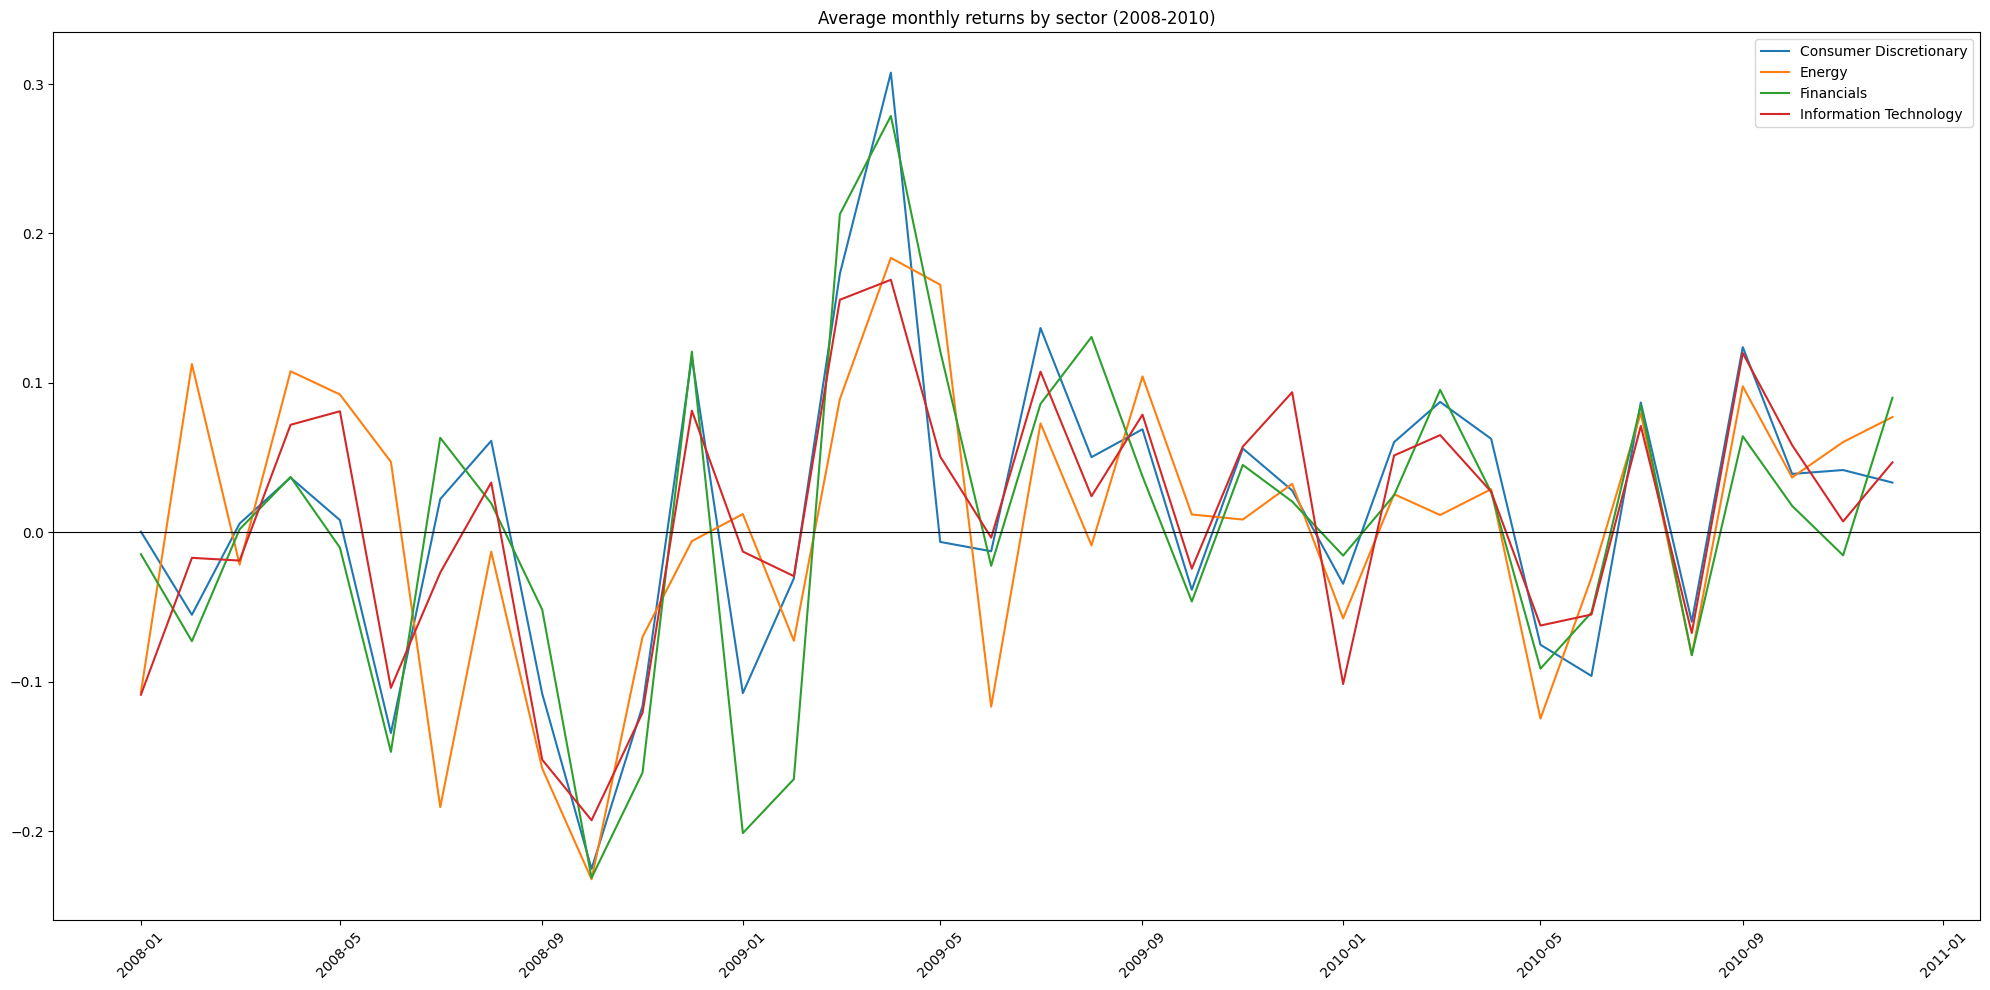

In [18]:

# Identify the year columns and strip out the year part
return_cols = [c for c in df.columns if c.startswith('avg')]
dates = pd.to_datetime([c[3:] for c in return_cols], format='%Y%m')

# extracting the date range, 2008‑2010, from columns
period_08_10 = (dates >= '2008-01-01') & (dates <= '2010-12-01')
cols_08_10 = np.array(return_cols)[period_08_10]

# create a list of
sector_list = ['Consumer Discretionary', 'Energy', 'Financials', 'Information Technology']
plt.figure(figsize=(20,10))
for sector in sector_list:
    sector_df = df[df['Industry'] == sector]
    plt.plot(dates[period_08_10], sector_df[cols_08_10].mean(), label=sector)
plt.axhline(0, color = 'black', linewidth = 0.8)
plt.title('Average monthly returns by sector (2008‑2010)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()



---

B.2 k-Means Clustering:
(a) Cluster the stocks into 4 clusters according to their monthly returns. Do not normalize
the data beforehand. Plot the centroids of the 4 clusters (each centroid is a time series,
so it can be plotted with time on the horizontal axis, and return on the vertical axis).
(b) Try multiple values of k and plot a Scree plot.
(c) What do you think is a reasonable number of clusters?
(d) For your chosen number of clusters, compute the number of companies in each cluster
and the number of companies per industry sector in each cluster.
(e) What was the average return for the worst cluster (as measured by returns) in October
2008? And the average return for the best cluster in March 2009?

---



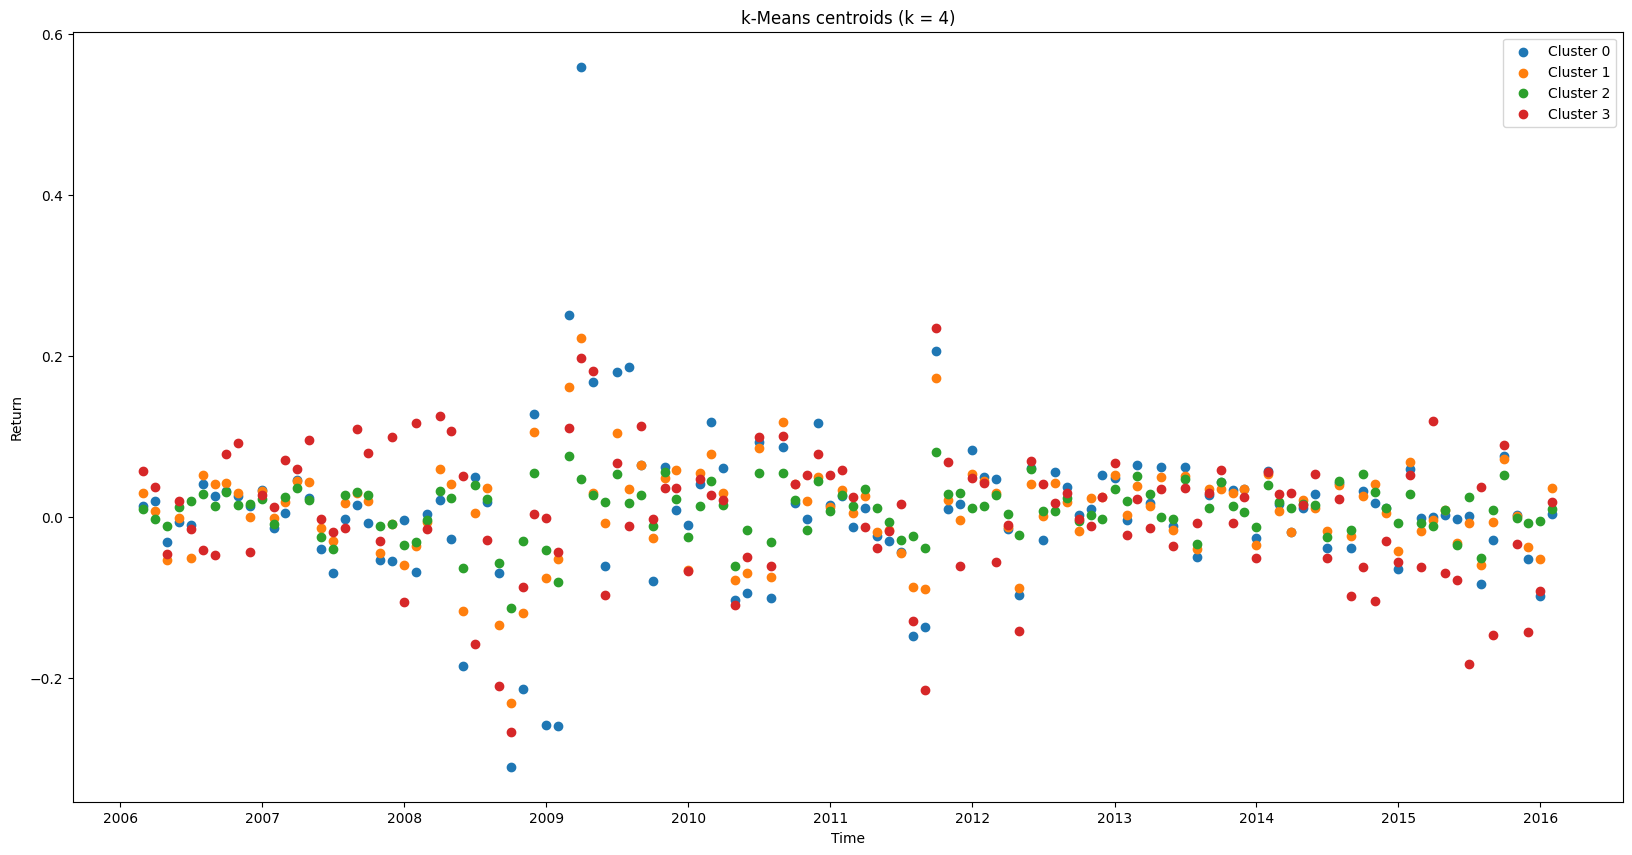

In [19]:
# Running k-Means clustering with k = 4
X = df[return_cols].values
k = 4
km = KMeans(n_clusters=k, n_init=20, random_state = 44)
km.fit(X)

# Centroid time‑series plot
plt.figure(figsize = (20,10))
for i in range(k):
    plt.scatter(dates, km.cluster_centers_[i], label=f'Cluster {i}')
plt.title('k‑Means centroids (k = 4)')
plt.xlabel('Time')
plt.ylabel('Return')
plt.legend()
plt.show()

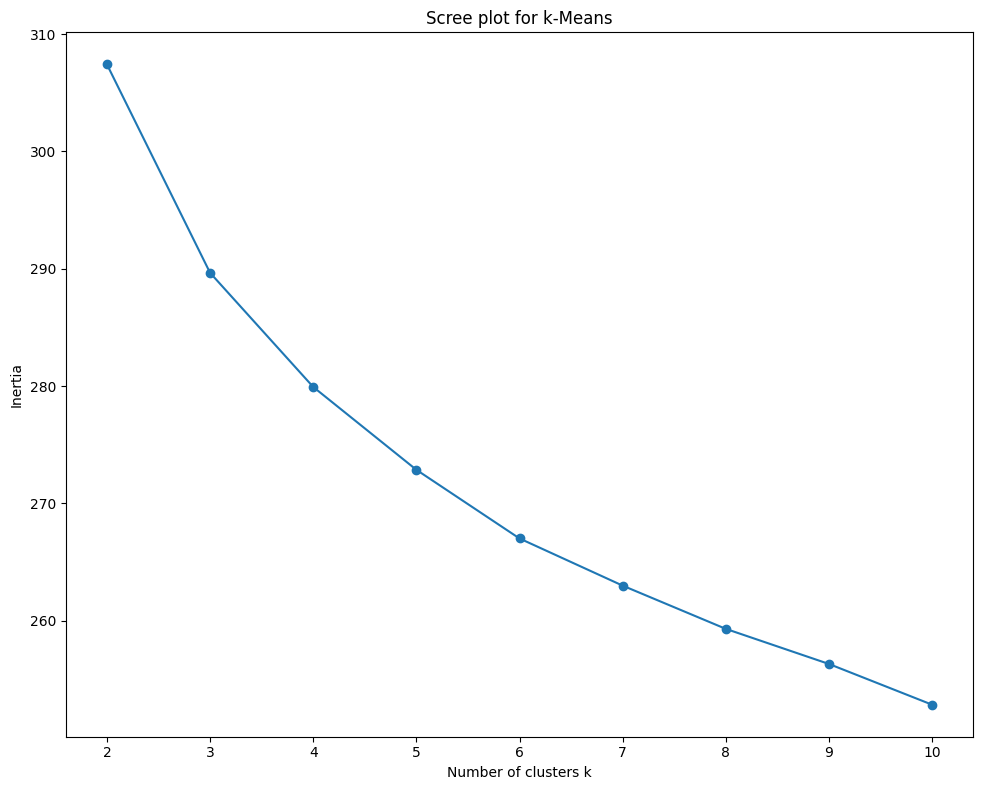

In [20]:
# Scree plot
ks = range(2,11)
WCSS = [KMeans(n_clusters=k,n_init=20).fit(X).inertia_ for k in ks]

# Finally, a standard scatter plot
plt.figure(figsize=(10, 8))
plt.title('Scree plot for k‑Means')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')
plt.tight_layout()
plt.plot(ks,WCSS, marker = 'o')
plt.show()

In [21]:
# using my chosen number of cluster = 4 from the original KMeans model to compute
df['cluster'] = km.fit_predict(X)

cluster_counts = df['cluster'].value_counts().sort_index()
industry_cluster = pd.crosstab(df['Industry'], df['cluster'])

print("Number of companies in each cluster:\n", cluster_counts)
print("\nNumber of companies per industry sector in each cluster:\n", industry_cluster)

Number of companies in each cluster:
 cluster
0     52
1    175
2    160
3     46
Name: count, dtype: int64

Number of companies per industry sector in each cluster:
 cluster                       0   1   2   3
Industry                                   
Consumer Discretionary       13  45  11   0
Consumer Staples              0   5  27   0
Energy                        0   2   3  33
Financials                   32  24  22   0
Health Care                   1  11  32   0
Industrials                   2  35  15   3
Information Technology        0  44  11   1
Materials                     4   9   8   7
Telecommunications Services   0   0   4   1
Utilities                     0   0  27   1


In [22]:
#calculating the average return for the worst and best cluster in Oct '08 and Mar '09
cluster_means_oct = (df.groupby('cluster')['avg200810'].mean()).min()
print(f'Average return for worst cluster in Oct 2008 is {cluster_means_oct}')

cluster_means_mar = (df.groupby('cluster')['avg200903'].mean()).max()
print(f'\nAverage return for best cluster in Mar 2009 is {cluster_means_mar}')

Average return for worst cluster in Oct 2008 is -0.31028269803846154

Average return for best cluster in Mar 2009 is 0.2504159093653846




---

B.3 Spectral Clustering:
(a) Spectral clustering will require us to input similarities for each pair of stocks. The most
natural notion of similarity in this context is probably correlation (the same correlation
from your statistics course). Why will correlations not work directly as the similarities
for spectral clustering?
(b) Propose a modification to correlation so that it can be used as the similarities for
spectral clustering (there are many correct answers).
(c) Run spectral clustering using your similarity from (b). Use the same number of clusters
you chose in B.2c.
Hint: The correlations of the columns of a pandas DataFrame df can be computed
with df.corr(). Or if you prefer numpy arrays, the correlations of the columns of a
2-D numpy array X can be computed with np.corrcoef(X, rowvar=False). (Setting
the argument rowvar to True will compute the correlations of the rows of X).
(d) In what ways are the clusters similar vs. different across this model and your model
from B.2?
5

---



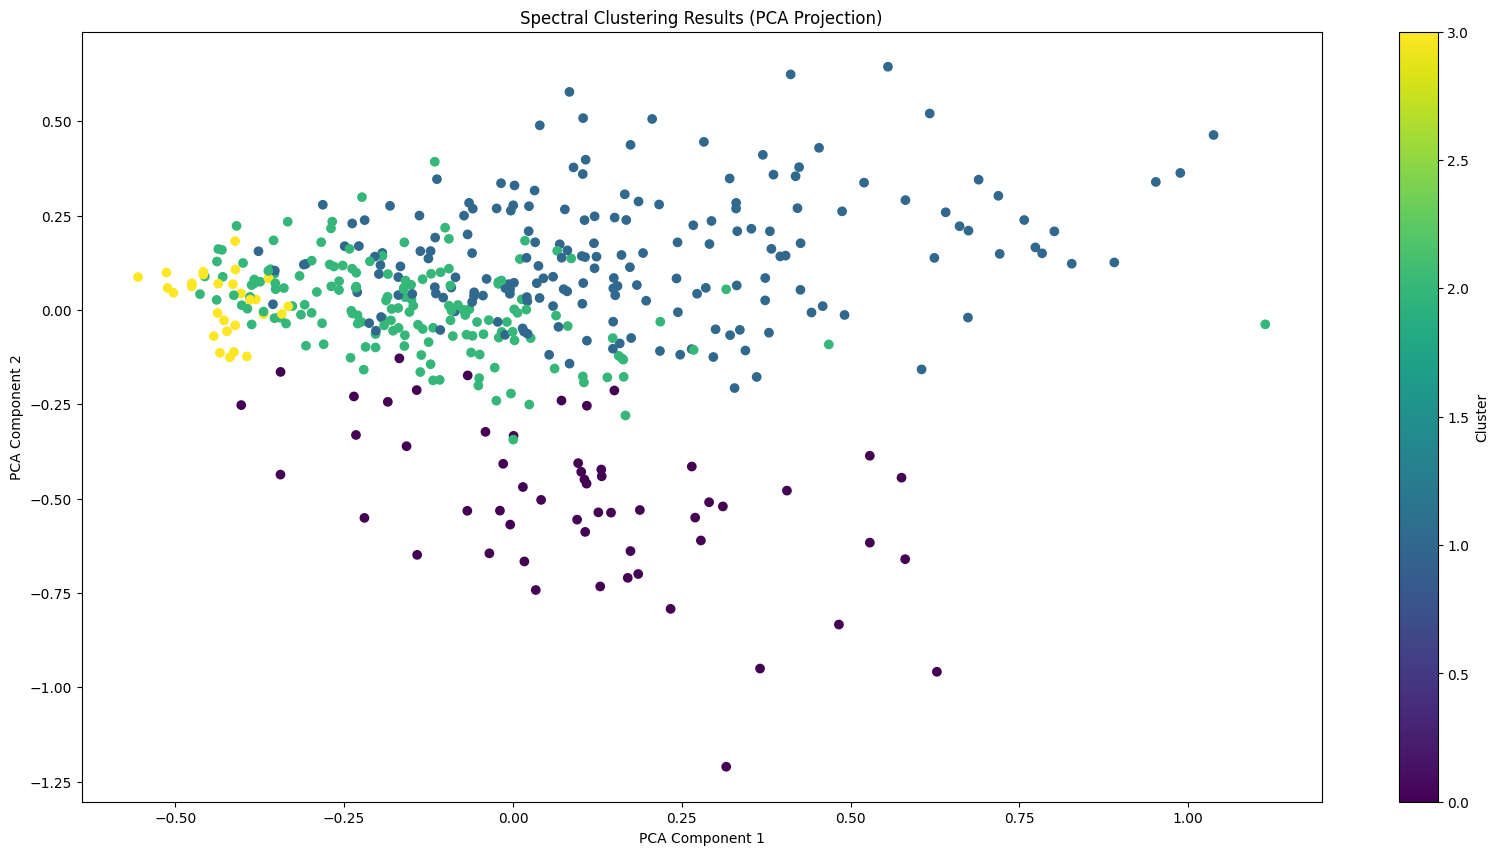

In [23]:
corr_matrix = np.corrcoef(X, rowvar = True)
dist_matrix = 1 - corr_matrix

# Apply Gaussian RBF kernel to distance matrix
sigma = 0.5
gamma = 1 / (2 * sigma**2)
sim_rbf = np.exp(-dist_matrix**2 * gamma)
np.fill_diagonal(sim_rbf, 1)

# Spectral clustering using RBF similarity
sc_rbf = SpectralClustering(n_clusters=4, affinity='precomputed', gamma = 10, random_state=0)
spec_rbf_clusters = sc_rbf.fit_predict(sim_rbf)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot RBF Spectral Clusters
plt.figure(figsize=(20, 10))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=spec_rbf_clusters) # Color by cluster labels
plt.title("Spectral Clustering Results (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster")  # Add a colorbar to show cluster mapping
plt.show()



In [24]:
# Assuming 'df' is your DataFrame and 'spec_rbf_clusters' contains the cluster labels
df['spec_cluster'] = spec_rbf_clusters  # Add cluster labels to DataFrame

# Number of companies in each cluster
cluster_counts_spec = df['spec_cluster'].value_counts().sort_index()
print("Number of companies in each spectral cluster:\n", cluster_counts_spec)

# Number of companies per industry sector in each cluster
industry_cluster_spec = pd.crosstab(df['Industry'], df['spec_cluster'])
print("\nNumber of companies per industry sector in each spectral cluster:\n", industry_cluster_spec)

Number of companies in each spectral cluster:
 spec_cluster
0     56
1    186
2    163
3     28
Name: count, dtype: int64

Number of companies per industry sector in each spectral cluster:
 spec_cluster                  0   1   2   3
Industry                                   
Consumer Discretionary        0  47  22   0
Consumer Staples              1   9  19   3
Energy                       36   0   2   0
Financials                    0  57  21   0
Health Care                   0   6  38   0
Industrials                   5  37  13   0
Information Technology        2  14  40   0
Materials                     9  14   5   0
Telecommunications Services   1   1   3   0
Utilities                     2   1   0  25
